<a href="https://colab.research.google.com/github/Sampavi01/Hotel_Revenue_Forecasting/blob/forecasting/Catboost_XGboost/Trial3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [30]:
# ================== IMPORTS ==================
import os
from datetime import timedelta, datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import OneHotEncoder

from catboost import CatBoostRegressor
import xgboost as xgb

# ================== CONFIG / CONSTANTS ==================
np.random.seed(42)

INPUT_FILE_NAME = 'Model_Training_Datasets.xlsx'
TEST_SET_DAYS = 60
MAPE_EPSILON = 1e-6

TARGET_RAW_COLS = ['Revenue_By_BreakFast', 'Revenue_By_Dinner', 'Revenue_By_Lunch']
LAG_DAYS = [1, 7, 14]
ROLL_WINDOWS = [7]

OUTPUT_DIR = 'github_results'


In [31]:
# ================== UTILITY FUNCTIONS ==================
def add_lag_and_rolling(df, target_cols, lag_days, roll_windows):
    df = df.copy()
    for col in target_cols:
        for lag in lag_days:
            df[f'{col}_lag{lag}'] = df[col].shift(lag)
        if pd.api.types.is_numeric_dtype(df[col]):
            for w in roll_windows:
                df[f'{col}_rollmean{w}'] = df[col].rolling(window=w, min_periods=1).mean().shift(1)
                df[f'{col}_rollstd{w}'] = df[col].rolling(window=w, min_periods=1).std().shift(1).fillna(0)
    return df.fillna(0)


def smape(y_true, y_pred, eps=MAPE_EPSILON):
    numer = np.abs(y_pred - y_true)
    denom = (np.abs(y_true) + np.abs(y_pred)).clip(min=eps)
    return np.mean(2.0 * numer / denom) * 100.0


def mae_np(y_true, y_pred):
    return np.mean(np.abs(y_true - y_pred))


# ================== PLOTTING ==================
def plot_test_results(test_df, center_name, meal_period):
    os.makedirs(OUTPUT_DIR, exist_ok=True)
    safe_name = center_name.replace(" ", "_")

    plt.figure(figsize=(12, 6))
    plt.plot(test_df['Date'], test_df['Actual_Revenue'], label='Actual Revenue', marker='o')
    plt.plot(test_df['Date'], test_df['Predicted_Revenue'], label='Predicted Revenue', marker='x')
    plt.title(f'Actual vs Predicted Revenue (Test) - {center_name} - {meal_period}')
    plt.xlabel('Date'); plt.ylabel('Revenue'); plt.legend()
    plt.grid(True, alpha=0.5); plt.xticks(rotation=45); plt.tight_layout()

    # Save AND show
    plt.savefig(f"{OUTPUT_DIR}/{safe_name}_{meal_period}_actual_vs_pred.png")
    plt.show()
    plt.close()



def plot_residuals_over_time(residuals_df, center_name, meal_period):
    os.makedirs(OUTPUT_DIR, exist_ok=True)
    safe_name = center_name.replace(" ", "_")

    residuals_df = residuals_df.copy()
    residuals_df['Residual'] = residuals_df['Actual_Revenue'] - residuals_df['Predicted_Revenue']
    plt.figure(figsize=(12, 5))
    plt.plot(residuals_df['Date'], residuals_df['Residual'], marker='.', linestyle='None', alpha=0.6)
    plt.axhline(0, color='red', linestyle='--')
    plt.title(f'Test Residuals Over Time - {center_name} - {meal_period}')
    plt.xlabel('Date'); plt.ylabel('Residual'); plt.grid(True, alpha=0.5)
    plt.xticks(rotation=45); plt.tight_layout()
    plt.savefig(f"{OUTPUT_DIR}/{safe_name}_{meal_period}_residuals.png")
    plt.close()


def save_training_curves_cat_xgb(center_name, meal_period, cat_evals, xgb_evals):
    os.makedirs(OUTPUT_DIR, exist_ok=True)
    safe_name = center_name.replace(" ", "_")

    plt.figure(figsize=(12, 6))

    if cat_evals is not None and 'learn' in cat_evals:
        if 'RMSE' in cat_evals['learn']:
            plt.plot(cat_evals['learn']['RMSE'], label='CatBoost Train RMSE', color='#1f77b4')
        if 'validation' in cat_evals and 'RMSE' in cat_evals['validation']:
            plt.plot(cat_evals['validation']['RMSE'], label='CatBoost Val RMSE', color='#ff7f0e')

    if xgb_evals is not None:
        if 'train' in xgb_evals and 'rmse' in xgb_evals['train']:
            plt.plot(xgb_evals['train']['rmse'], label='XGBoost Train RMSE', color='#2ca02c')
        if 'valid' in xgb_evals and 'rmse' in xgb_evals['valid']:
            plt.plot(xgb_evals['valid']['rmse'], label='XGBoost Val RMSE', color='#d62728')

    plt.title(f'Training Curves: {center_name} - {meal_period} (CatBoost + XGBoost)')
    plt.xlabel('Iterations'); plt.ylabel('RMSE')
    plt.legend(loc='upper right'); plt.grid(True, linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.savefig(f"{OUTPUT_DIR}/{safe_name}_{meal_period}_metrics.png")
    plt.close()


In [32]:

# ================== DATA LOADER ==================
def load_center_from_excel(file_path, center_sheet_name):
    df = pd.read_excel(file_path, sheet_name=center_sheet_name)
    if 'Date' in df.columns:
        df['Date'] = pd.to_datetime(df['Date'])
    else:
        raise ValueError("Expected a 'Date' column in the sheet.")
    return df

In [33]:
# ================== TRAINING: CATBOOST + XGBOOST ==================
def train_and_plot_for_center_cat_xgb(
    df_center,
    center_name,
    cat_params=None,
    xgb_params=None,
    w_cat=0.7,
    w_xgb=0.3
):
    # --- Feature engineering ---
    df_center = add_lag_and_rolling(df_center, TARGET_RAW_COLS, LAG_DAYS, ROLL_WINDOWS)
    df_center = df_center.sort_values('Date').reset_index(drop=True)

    # --- Train/test split ---
    max_date = df_center['Date'].max()
    test_start_date = max_date - timedelta(days=TEST_SET_DAYS)
    df_train_full = df_center[df_center['Date'] < test_start_date].copy().dropna()
    df_test_full = df_center[df_center['Date'] >= test_start_date].copy()

    if df_train_full.empty or df_test_full.empty:
        print(f"Skipping center {center_name}: Training or Test set is empty.")
        return

    # --- Features ---
    feature_cols = [c for c in df_train_full.columns if c not in ['Date'] + TARGET_RAW_COLS]
    numeric_features = [c for c in feature_cols if pd.api.types.is_numeric_dtype(df_train_full[c])]
    categorical_features = [c for c in feature_cols if c not in numeric_features]

    X_train = df_train_full[feature_cols].copy()
    X_test = df_test_full[feature_cols].copy()

    summary_rows = []

    # --- Default params ---
    if cat_params is None:
        cat_params = {"iterations": 300, "learning_rate": 0.005, "depth": 6,
                      "loss_function": "RMSE", "random_seed": 42, "verbose": False}
    if xgb_params is None:
        xgb_params = {"objective": "reg:squarederror", "learning_rate": 0.005,
                      "max_depth": 6, "n_estimators": 300, "subsample": 0.9,
                      "colsample_bytree": 0.9, "reg_lambda": 1.0, "random_state": 42}

    # --- One-hot encode categoricals for XGB ---
    if len(categorical_features) > 0:
        try:
            ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
        except TypeError:
            ohe = OneHotEncoder(handle_unknown='ignore', sparse=False)

        ohe_train = ohe.fit_transform(X_train[categorical_features])
        ohe_test = ohe.transform(X_test[categorical_features])

        try:
            ohe_cols = ohe.get_feature_names_out(categorical_features)
        except AttributeError:
            ohe_cols = [f"ohe_{i}" for i in range(ohe_train.shape[1])]

        X_train_xgb = pd.concat(
            [pd.DataFrame(X_train[numeric_features].values, columns=numeric_features, index=X_train.index),
             pd.DataFrame(ohe_train, columns=ohe_cols, index=X_train.index)],
            axis=1
        )
        X_test_xgb = pd.concat(
            [pd.DataFrame(X_test[numeric_features].values, columns=numeric_features, index=X_test.index),
             pd.DataFrame(ohe_test, columns=ohe_cols, index=X_test.index)],
            axis=1
        )
    else:
        X_train_xgb = X_train[numeric_features].copy()
        X_test_xgb = X_test[numeric_features].copy()

    cat_feature_indices = [X_train.columns.get_loc(c) for c in categorical_features]

    # ================== LOOP OVER MEAL PERIODS ==================
    for raw_target_col in TARGET_RAW_COLS:
        meal_period = raw_target_col.replace("Revenue_By_", "")

        # Prepare target
        y_train = df_train_full[raw_target_col].values
        y_test = df_test_full[raw_target_col].values

        # --- Train CatBoost ---
        cat_model = CatBoostRegressor(**cat_params)
        cat_model.fit(
            X_train, y_train,
            cat_features=cat_feature_indices,
            eval_set=(X_test, y_test),
            verbose=False
        )
        y_pred_cat = cat_model.predict(X_test)
        cat_evals = cat_model.get_evals_result()

        # --- Train XGBoost ---
        dtrain = xgb.DMatrix(X_train_xgb, label=y_train)
        dtest = xgb.DMatrix(X_test_xgb, label=y_test)

        xgb_model = xgb.train(
            params=xgb_params,
            dtrain=dtrain,
            num_boost_round=xgb_params.get("n_estimators", 300),
            evals=[(dtrain, "train"), (dtest, "valid")],
            verbose_eval=False
        )
        y_pred_xgb = xgb_model.predict(dtest)
        try:
            xgb_evals = xgb_model.evals_result()
        except Exception:
            xgb_evals = None

        # --- Ensemble predictions ---
        y_pred_ens = (w_cat * y_pred_cat) + (w_xgb * y_pred_xgb)

        # --- Metrics ---
        rmse_val = np.sqrt(mean_squared_error(y_test, y_pred_ens))
        mape_val = np.mean(np.abs((y_test - y_pred_ens) / (y_test + MAPE_EPSILON))) * 100.0
        smape_val = smape(y_test, y_pred_ens)

        print(f"📈 {center_name} - {meal_period}: RMSE={rmse_val:.2f}, MAPE={mape_val:.2f}%, SMAPE={smape_val:.2f}%")

        # --- Plots ---
        plot_df = pd.DataFrame({
            "Date": df_test_full["Date"],
            "Actual_Revenue": y_test,
            "Predicted_Revenue": y_pred_ens
        })
        plot_test_results(plot_df, center_name, meal_period)
        plot_residuals_over_time(plot_df, center_name, meal_period)
        save_training_curves_cat_xgb(center_name, meal_period, cat_evals, xgb_evals)

        # --- Summary row ---
        summary_rows.append({
            "Center": center_name,
            "Meal_Period": meal_period,
            "Weight_CatBoost": w_cat,
            "Weight_XGBoost": w_xgb,
            "RMSE": rmse_val,
            "MAPE": mape_val,
            "SMAPE": smape_val
        })

    # ================== SAVE SUMMARY ==================
    summary_df = pd.DataFrame(summary_rows)
    os.makedirs(OUTPUT_DIR, exist_ok=True)
    summary_path = os.path.join(OUTPUT_DIR, f"{center_name.replace(' ', '_')}_summary.csv")
    summary_df.to_csv(summary_path, index=False)
    print(f"📄 Saved summary: {summary_path}")
    print(summary_df)


================= Revenue Centre 1 =================


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [09:16:48] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "n_estimators" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


📈 Revenue Centre 1 - BreakFast: RMSE=1073.16, MAPE=953549321.23%, SMAPE=56.67%


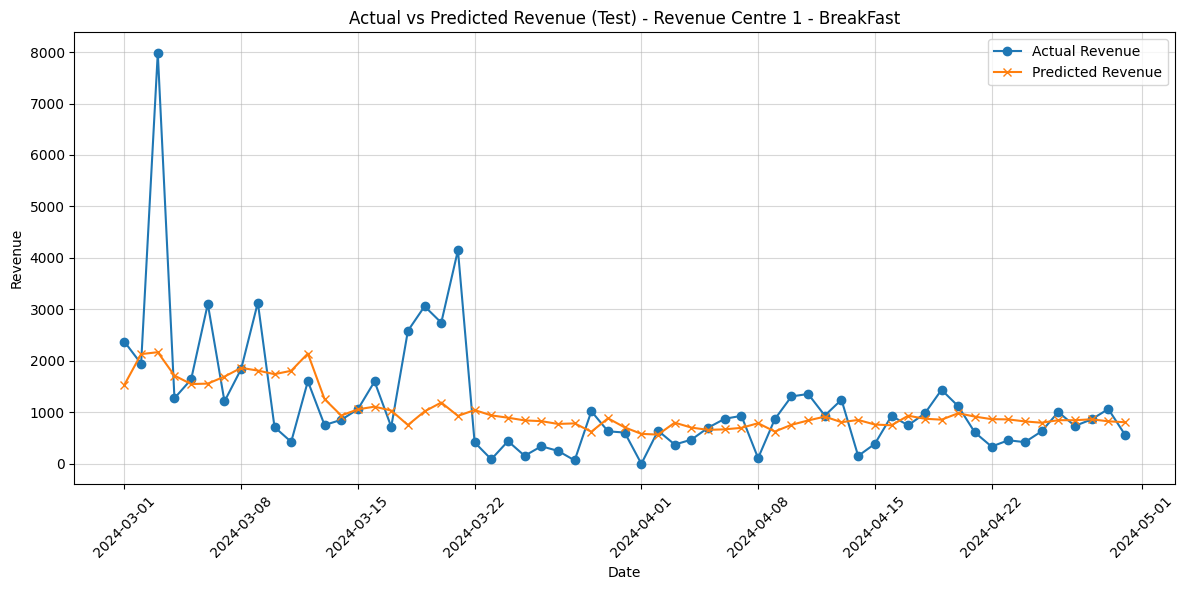

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [09:16:51] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "n_estimators" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


📈 Revenue Centre 1 - Dinner: RMSE=1617.45, MAPE=67.14%, SMAPE=43.59%


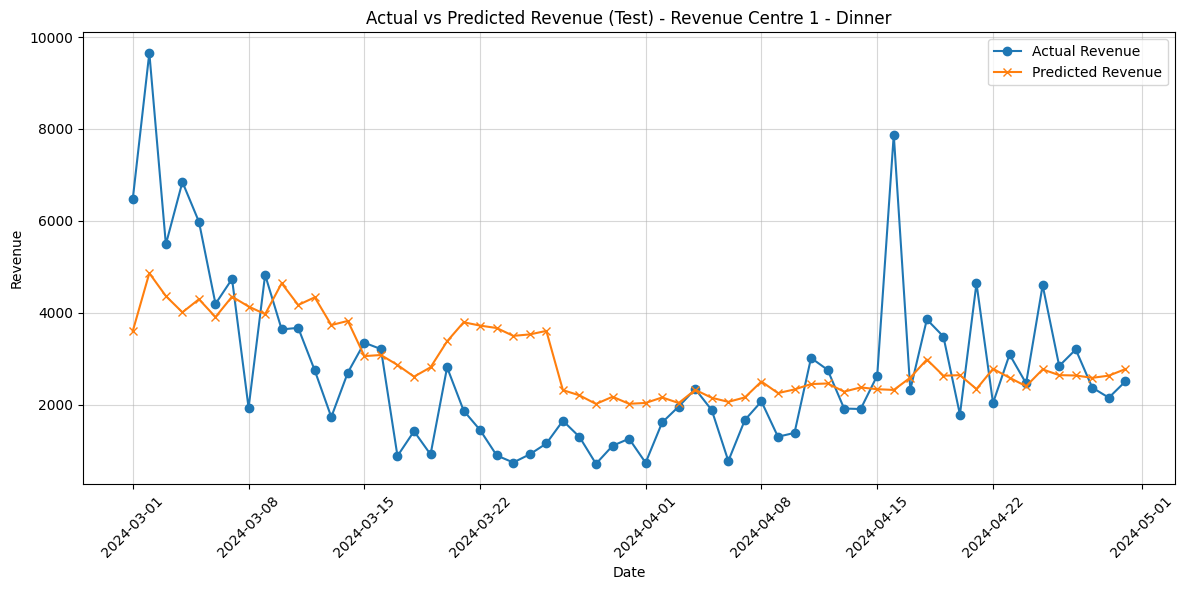

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [09:16:55] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "n_estimators" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


📈 Revenue Centre 1 - Lunch: RMSE=653.96, MAPE=2292396918.32%, SMAPE=66.82%


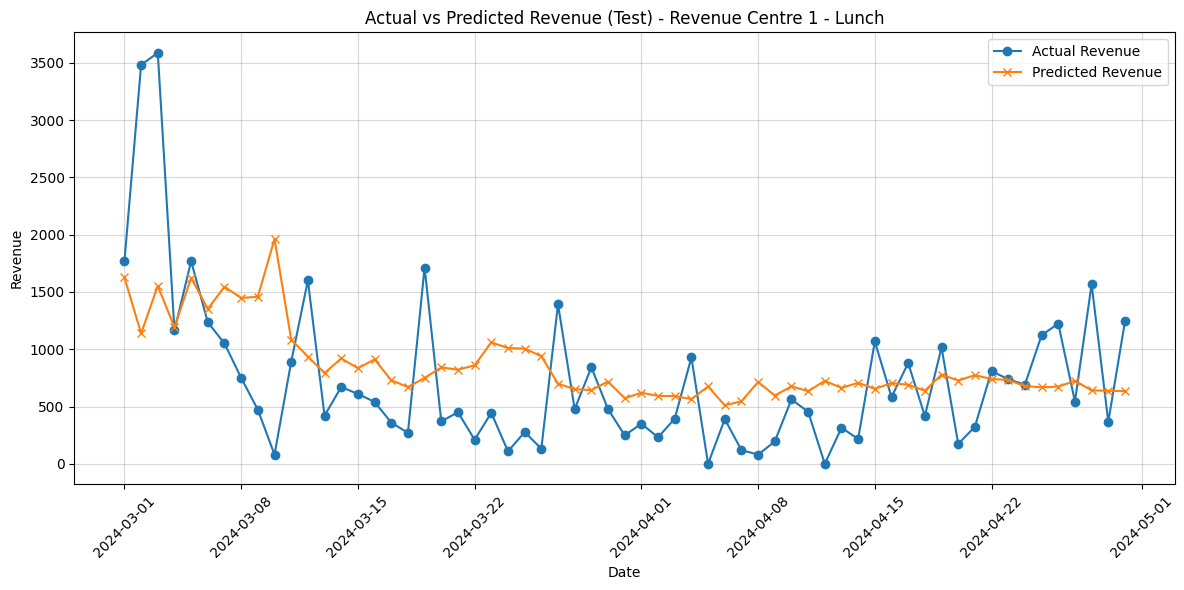

📄 Saved summary: github_results/Revenue_Centre_1_summary.csv
             Center Meal_Period  Weight_CatBoost  Weight_XGBoost         RMSE  \
0  Revenue Centre 1   BreakFast              0.3             0.7  1073.158675   
1  Revenue Centre 1      Dinner              0.3             0.7  1617.449501   
2  Revenue Centre 1       Lunch              0.3             0.7   653.957728   

           MAPE      SMAPE  
0  9.535493e+08  56.674786  
1  6.714457e+01  43.586288  
2  2.292397e+09  66.815252  

================= Revenue Centre 2 =================


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [09:16:58] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "n_estimators" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


📈 Revenue Centre 2 - BreakFast: RMSE=482.95, MAPE=9541476471.87%, SMAPE=101.93%


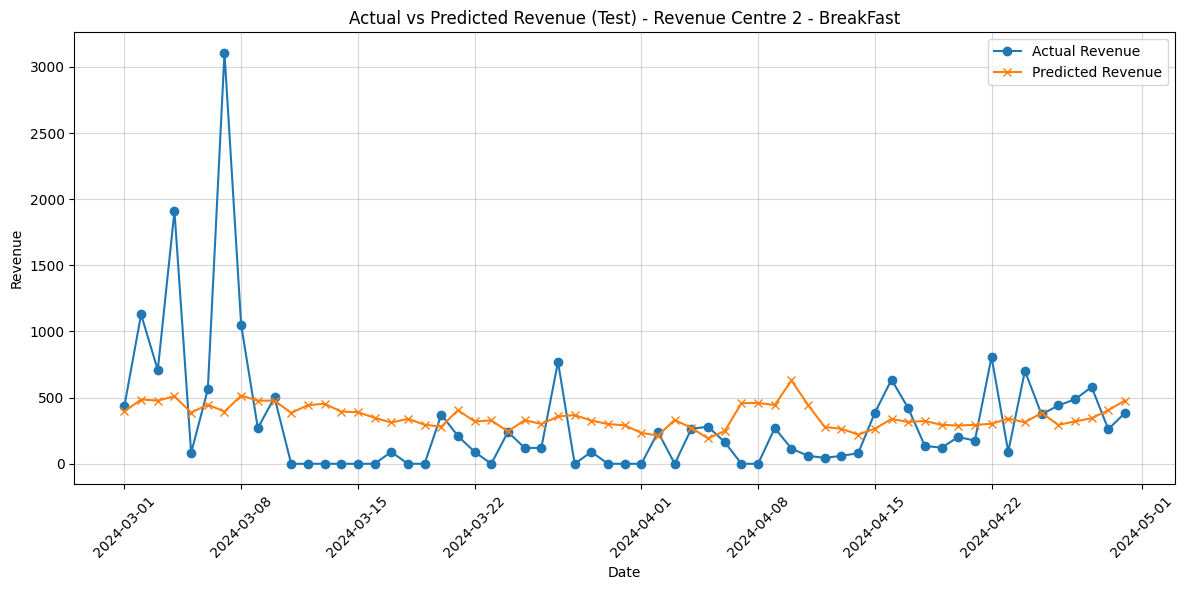

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [09:17:03] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "n_estimators" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


📈 Revenue Centre 2 - Dinner: RMSE=732.56, MAPE=9241723993.27%, SMAPE=93.98%


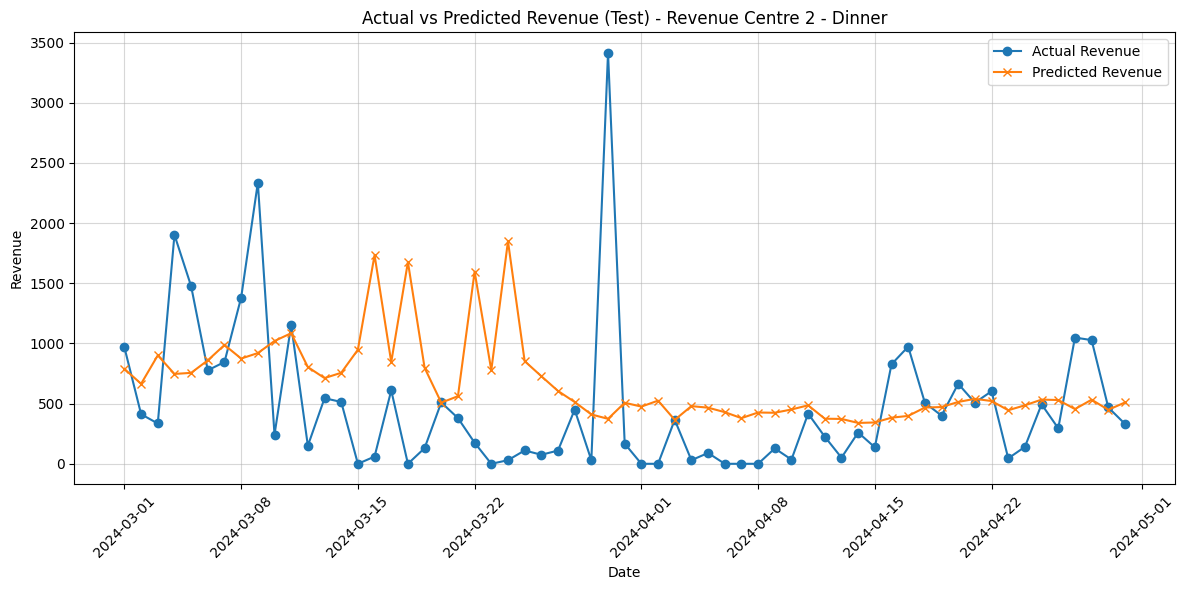

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [09:17:06] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "n_estimators" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


📈 Revenue Centre 2 - Lunch: RMSE=924.48, MAPE=6430040945.47%, SMAPE=90.04%


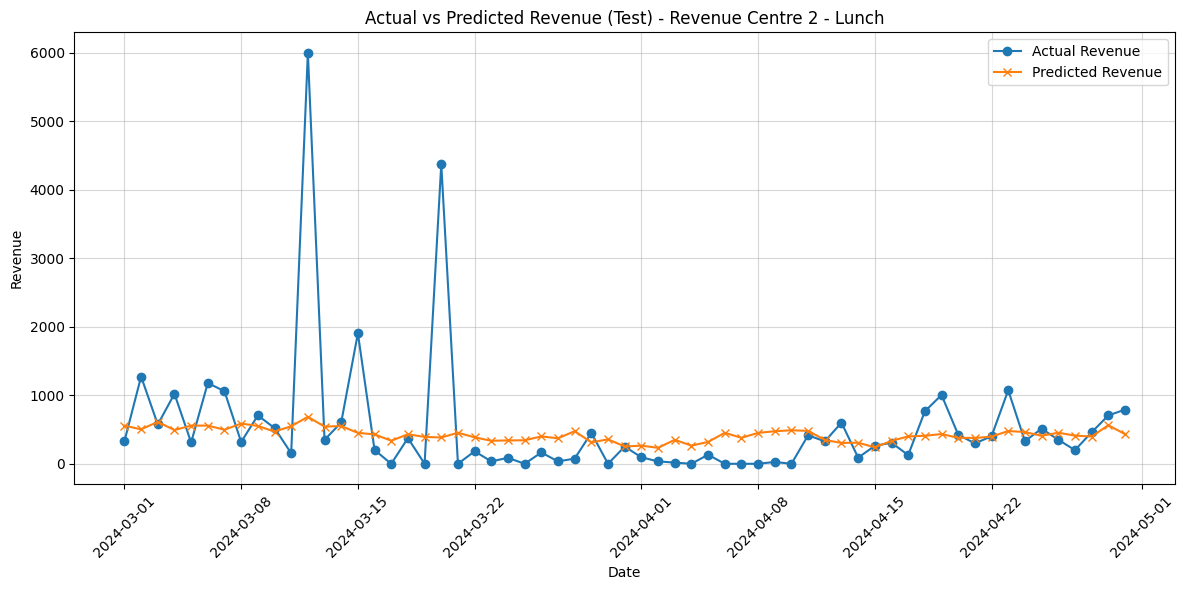

📄 Saved summary: github_results/Revenue_Centre_2_summary.csv
             Center Meal_Period  Weight_CatBoost  Weight_XGBoost        RMSE  \
0  Revenue Centre 2   BreakFast              0.3             0.7  482.951021   
1  Revenue Centre 2      Dinner              0.3             0.7  732.561894   
2  Revenue Centre 2       Lunch              0.3             0.7  924.483361   

           MAPE       SMAPE  
0  9.541476e+09  101.930071  
1  9.241724e+09   93.980493  
2  6.430041e+09   90.043002  


In [34]:
# ================== RUN ==================
if __name__ == "__main__":
    for center_id in range(0, 2):  # adjust range for multiple centers
        try:
            df_center = load_center_from_excel(INPUT_FILE_NAME, center_id)
            display_name = f"Revenue Centre {center_id+1}"
            print(f"\n================= {display_name} =================")
            train_and_plot_for_center_cat_xgb(
                df_center,
                display_name,
                w_cat=0.3,
                w_xgb=0.7
            )
        except Exception as e:
            print(f"⚠️ Skipping {center_id}: {e}")


================= Revenue Centre 3 =================


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [09:17:10] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "n_estimators" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


📈 Revenue Centre 3 - BreakFast: RMSE=313.13, MAPE=8102981332.02%, SMAPE=97.64%


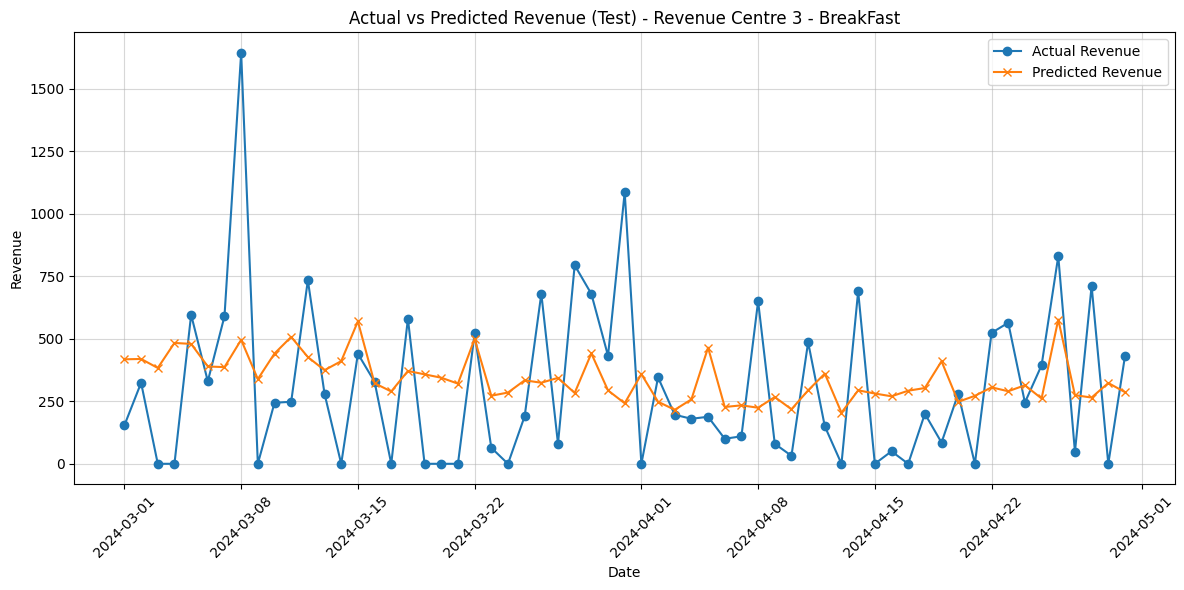

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [09:17:16] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "n_estimators" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


📈 Revenue Centre 3 - Dinner: RMSE=8963.26, MAPE=39.80%, SMAPE=32.18%


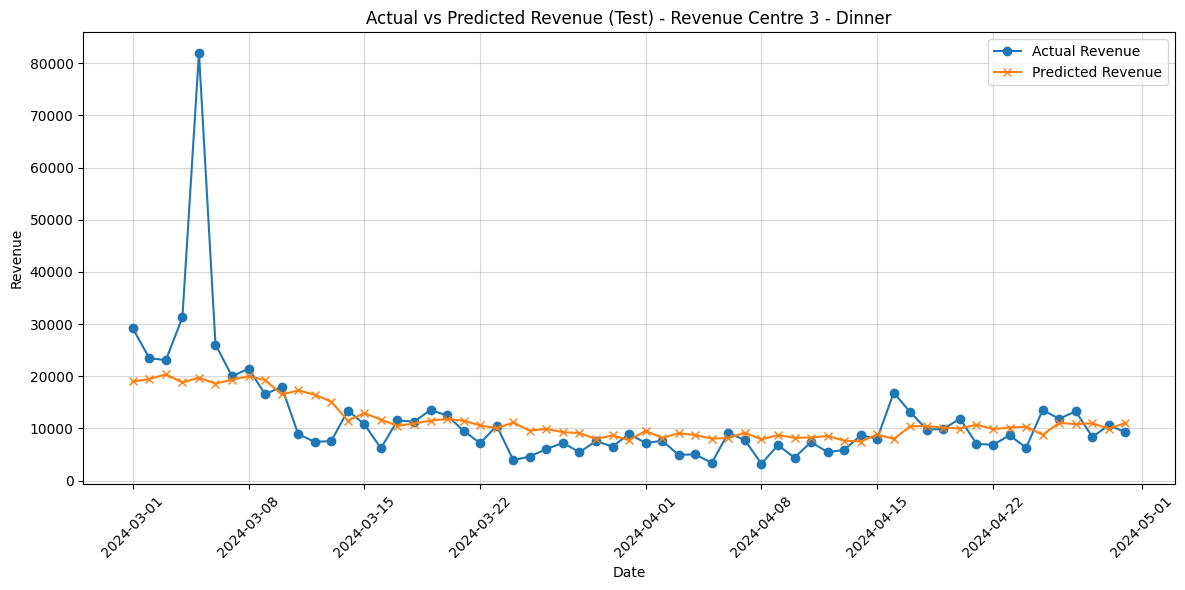

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [09:17:19] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "n_estimators" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


📈 Revenue Centre 3 - Lunch: RMSE=1033.94, MAPE=48.73%, SMAPE=39.89%


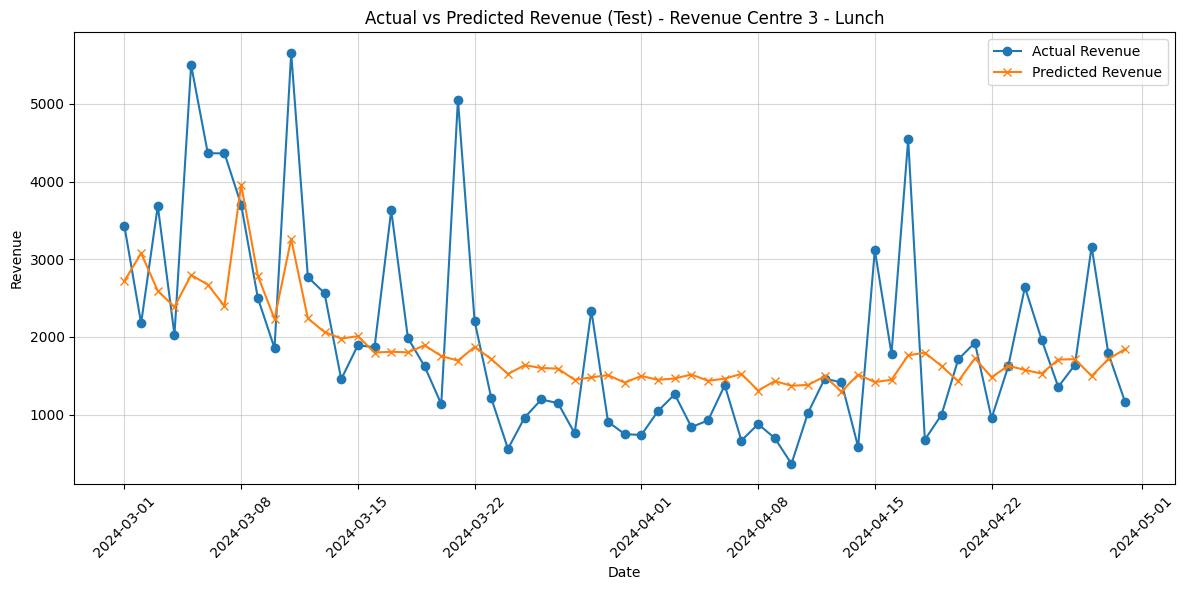

📄 Saved summary: github_results/Revenue_Centre_3_summary.csv
             Center Meal_Period  Weight_CatBoost  Weight_XGBoost         RMSE  \
0  Revenue Centre 3   BreakFast              0.5             0.5   313.134194   
1  Revenue Centre 3      Dinner              0.5             0.5  8963.263010   
2  Revenue Centre 3       Lunch              0.5             0.5  1033.942759   

           MAPE      SMAPE  
0  8.102981e+09  97.635556  
1  3.979735e+01  32.180892  
2  4.872837e+01  39.894231  

================= Revenue Centre 4 =================
⚠️ Skipping 3: catboost/libs/metrics/metric.cpp:6935: All train targets are equal

================= Revenue Centre 5 =================


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [09:17:23] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "n_estimators" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


📈 Revenue Centre 5 - BreakFast: RMSE=3269.29, MAPE=17.42%, SMAPE=15.82%


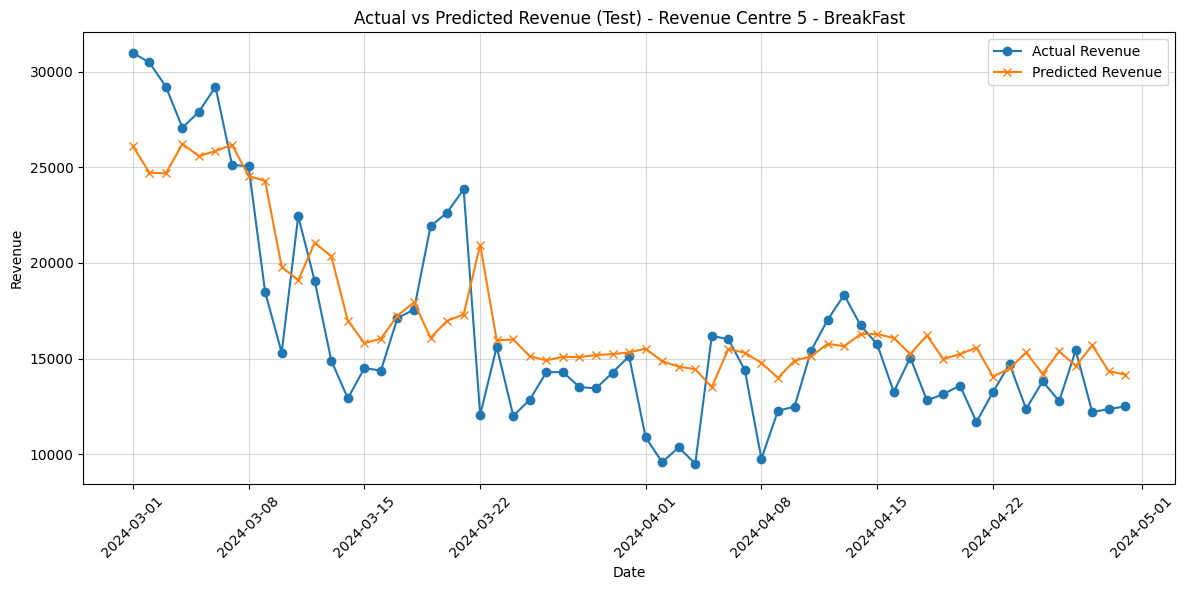

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [09:17:28] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "n_estimators" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


📈 Revenue Centre 5 - Dinner: RMSE=10265.54, MAPE=62.09%, SMAPE=52.11%


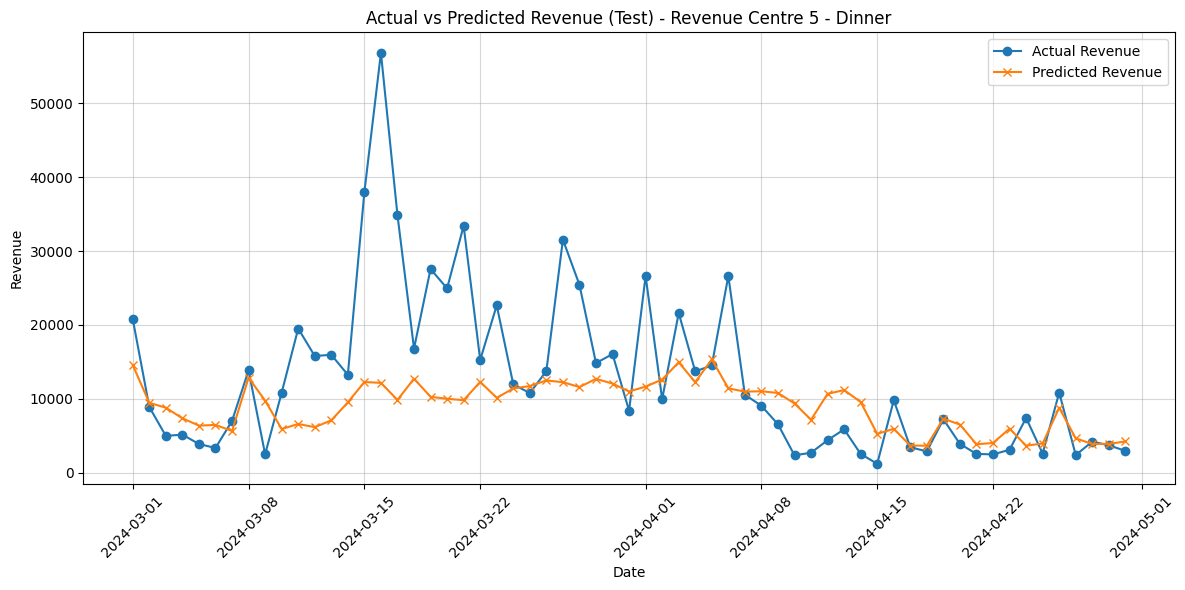

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [09:17:31] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "n_estimators" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


📈 Revenue Centre 5 - Lunch: RMSE=3454.59, MAPE=7008819154.93%, SMAPE=90.09%


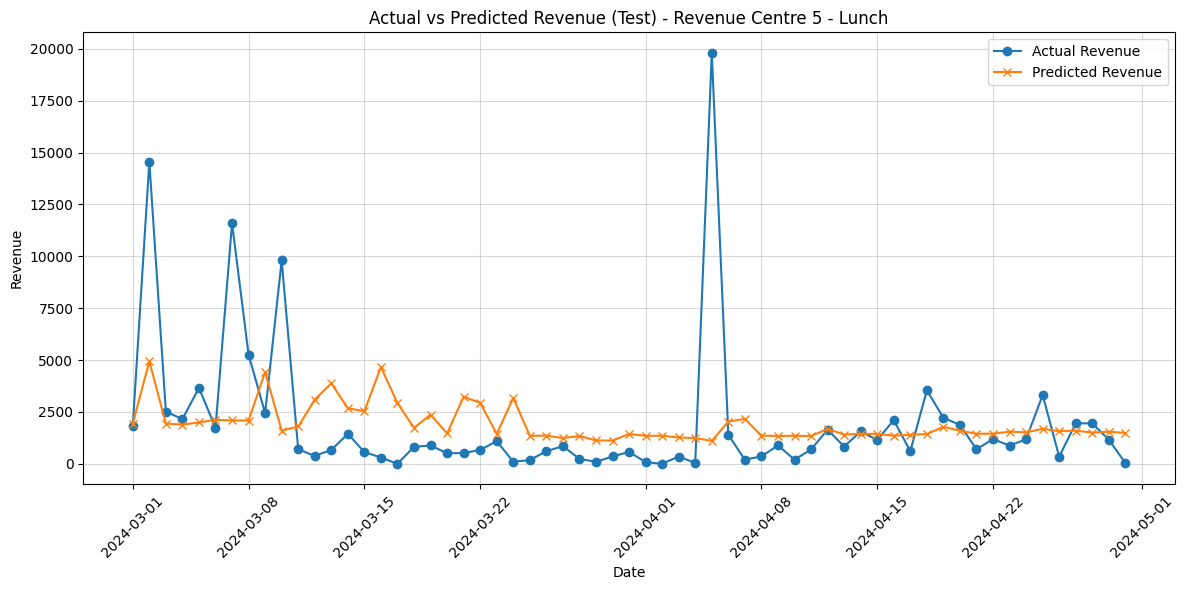

📄 Saved summary: github_results/Revenue_Centre_5_summary.csv
             Center Meal_Period  Weight_CatBoost  Weight_XGBoost  \
0  Revenue Centre 5   BreakFast              0.5             0.5   
1  Revenue Centre 5      Dinner              0.5             0.5   
2  Revenue Centre 5       Lunch              0.5             0.5   

           RMSE          MAPE      SMAPE  
0   3269.292088  1.742127e+01  15.822894  
1  10265.542916  6.208803e+01  52.105071  
2   3454.589522  7.008819e+09  90.089728  


In [35]:
# ================== RUN ==================
if __name__ == "__main__":
    for center_id in range(2, 5):  # adjust range for multiple centers
        try:
            df_center = load_center_from_excel(INPUT_FILE_NAME, center_id)
            display_name = f"Revenue Centre {center_id+1}"
            print(f"\n================= {display_name} =================")
            train_and_plot_for_center_cat_xgb(
                df_center,
                display_name,
                w_cat=0.5,
                w_xgb=0.5
            )
        except Exception as e:
            print(f"⚠️ Skipping {center_id}: {e}")